### **Spam Detection Project**

1.Load Library
2.Load Dataset
3.Exploratory Data Analysis
4.Preprocessing
5.Baseline Model
6.Model Selection
7.Hyperparameter Tuning
8.Evaluation 
9.Predictive System

### **1.Load Library**

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from  sklearn.model_selection import train_test_split,RandomizedSearchCV,StratifiedKFold,cross_validate
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,HistGradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import BernoulliNB
# for Text
import re
from sklearn.feature_extraction.text import (
    ENGLISH_STOP_WORDS,
    TfidfVectorizer
)

In [2]:
# configurations
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

plt.rcParams.update({
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

### **2.Load Dataset**

In [3]:
df = pd.read_csv("spam.csv",encoding = "latin-1")

In [4]:
df.shape

(5572, 5)

In [5]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


### **Exploratory Data Analysis**

In [6]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [7]:
df.isna().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [8]:
for col in df.columns:
    print(df[col].value_counts().head(20))

v1
ham     4825
spam     747
Name: count, dtype: int64
v2
Sorry, I'll call later                                                                                                                                                                 30
I cant pick the phone right now. Pls send a message                                                                                                                                    12
Ok...                                                                                                                                                                                  10
Your opinion about me? 1. Over 2. Jada 3. Kusruthi 4. Lovable 5. Silent 6. Spl character 7. Not matured 8. Stylish 9. Simple Pls reply..                                                4
Say this slowly.? GOD,I LOVE YOU &amp; I NEED YOU,CLEAN MY HEART WITH YOUR BLOOD.Send this to Ten special people &amp; u c miracle tomorrow, do it,pls,pls do it...                     4
Okie        

In [9]:
df = df.drop(columns = ["Unnamed: 2","Unnamed: 3","Unnamed: 4"])

In [10]:
df.columns

Index(['v1', 'v2'], dtype='object')

In [11]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
df["v1"].value_counts()

v1
ham     4825
spam     747
Name: count, dtype: int64

In [13]:
df["v1"] = df["v1"].replace({
 "ham":"not spam",
  "spam":"spam"
})

In [14]:
df["v1"].value_counts()

v1
not spam    4825
spam         747
Name: count, dtype: int64

1 ---> Spam
0 ---> Notspam

In [15]:
df["v1"] = df["v1"].map({"spam":1,"not spam":0})

In [16]:
df["v1"].value_counts()

v1
0    4825
1     747
Name: count, dtype: int64

In [17]:
def clean_text(s:str)->str:
    """
    Simple text cleaning:
    - lowercasing
    - remove URLs
    - remove HTML tags
    - keep letters/numbers and basic punctuation
    - normalize spaces
    """
    if pd.isna(s):
        return ""
    s = str(s).lower()
    s = re.sub(r"http\S+|www\.\S+", " ", s)          # URLs
    s = re.sub(r"<.*?>", " ", s)                    # HTML tags
    s = re.sub(r"[^a-z0-9\s\.\,\!\?\-\']", " ", s)   # keep basic chars
    s = re.sub(r"\s+", " ", s).strip()               # normalize spaces
    return s

In [18]:
a = "Saurabh*"
b = "Agrawal"
c = a+b
print(c)
d = clean_text(c)
print(d)

Saurabh*Agrawal
saurabh agrawal


In [19]:
df["content"] = df["v2"].apply(clean_text)

In [20]:
df.head()

,v1,v2,content
0,0,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ..."
1,0,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,0,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro...","nah i don't think he goes to usf, he lives aro..."


In [21]:
# adding additional text
df["v2_len"] = df["v2"].str.len()
df["context_len"] = df["content"].str.len()

In [22]:
df.head()

,v1,v2,content,v2_len,context_len
0,0,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ...",111,111
1,0,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...,29,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...,155,155
3,0,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...,49,49
4,0,"Nah I don't think he goes to usf, he lives aro...","nah i don't think he goes to usf, he lives aro...",61,61


**Visualization**

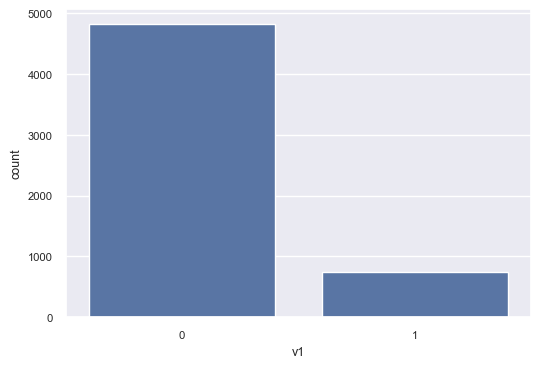

In [23]:
plt.figure(figsize = (6,4))
sns.countplot(x = "v1",data = df)
plt.show()

**Note : Data Imbalance**

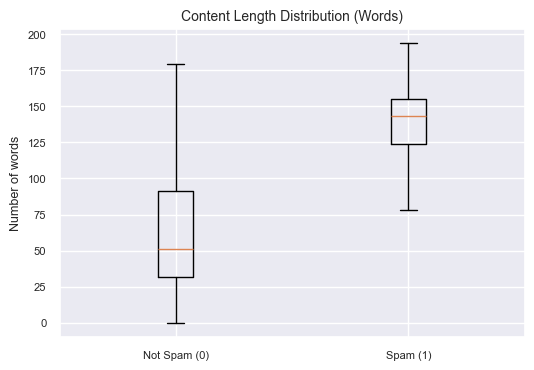

In [24]:
# text length distribution (words) - boxplot
Not_spam = df[df["v1"] == 0]["context_len"].values
spam = df[df["v1"] == 1]["context_len"].values

plt.figure(figsize=(6,4))
plt.boxplot(
    [Not_spam, spam],
    tick_labels=["Not Spam (0)", "Spam (1)"],
    showfliers=False
)
plt.title("Content Length Distribution (Words)")
plt.ylabel("Number of words")
plt.show()

### **4.Preprocessing**

In [25]:
df.head()

,v1,v2,content,v2_len,context_len
0,0,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ...",111,111
1,0,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...,29,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...,155,155
3,0,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...,49,49
4,0,"Nah I don't think he goes to usf, he lives aro...","nah i don't think he goes to usf, he lives aro...",61,61


In [26]:
X = df["content"]
y = df["v1"]

In [27]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    stratify = y,
    random_state = 42 
)

In [28]:
print("Shape of X:",X.shape)
print("Shape of X_train:",X_train.shape)
print("Shape of X_test:",X_test.shape)
print("Shape of y_train:",y_train.shape)
print("Shape of y_test:",y_test.shape)

Shape of X: (5572,)
Shape of X_train: (4457,)
Shape of X_test: (1115,)
Shape of y_train: (4457,)
Shape of y_test: (1115,)


---

**What does TF-IDF mean?**

TF-IDF stands for:

Term Frequency – Inverse Document Frequency
- Term Frequency (TF): How often a word appears in a single document.
- Inverse Document Frequency (IDF): How rare that word is across all documents.

⸻

**How less important words get less importance**

Think of words like:
the, is, and, to

These words:
- Appear in almost every document
- Do not help distinguish fake vs real news

So TF-IDF does this:
- If a word appears many times in one document → its TF increases
- If the same word appears in almost all documents → its IDF becomes very small
- Final weight = TF × IDF

Result:
- Common words → low TF-IDF score
- Rare but meaningful words → high TF-IDF score

---

**Simple Intuition:**

TF-IDF rewards words that are frequent in a document but uncommon in the overall dataset. Words that appear everywhere are treated as less important.


In [29]:
model_pipeline = Pipeline(
    steps = [
        ("tfidf",TfidfVectorizer(
            max_features = 50000,
            ngram_range = (1,2),
            stop_words = "english",
            min_df =2
        )),
        ("model",LogisticRegression(class_weight = "balanced"))
    ]
)

In [30]:
model_pipeline.fit(X_train,y_train)

,steps,"[('tfidf', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


**Evaluation**

In [31]:
y_pred_train = model_pipeline.predict(X_train)
y_proba_train = model_pipeline.predict_proba(X_train)[:, 1]

acc_train = accuracy_score(y_train, y_pred_train)
cm_train = confusion_matrix(y_train, y_pred_train)

print("\n--- Train Metrics ---")
print(f"Accuracy : {acc_train:.4f}")

print("\nConfusion Matrix [ [TN FP], [FN TP] ]:")
print(cm_train)

print("\nClassification Report:")
print(classification_report(y_train, y_pred_train, digits=4))


--- Train Metrics ---
Accuracy : 0.9926

Confusion Matrix [ [TN FP], [FN TP] ]:
[[3833   26]
 [   7  591]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9982    0.9933    0.9957      3859
           1     0.9579    0.9883    0.9728       598

    accuracy                         0.9926      4457
   macro avg     0.9780    0.9908    0.9843      4457
weighted avg     0.9928    0.9926    0.9926      4457



In [32]:
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

print("\n--- Test Metrics ---")
print(f"Accuracy : {acc:.4f}")

print("\nConfusion Matrix [ [TN FP], [FN TP] ]:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


--- Test Metrics ---
Accuracy : 0.9848

Confusion Matrix [ [TN FP], [FN TP] ]:
[[958   8]
 [  9 140]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9907    0.9917    0.9912       966
           1     0.9459    0.9396    0.9428       149

    accuracy                         0.9848      1115
   macro avg     0.9683    0.9657    0.9670      1115
weighted avg     0.9847    0.9848    0.9847      1115



### **Model Selection**

In [33]:
models ={
       
    "LogisticRegression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ),
    
    "DecisionTree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),
    
    "RandomForest": RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ),
    
    "XGBClassifier": XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ),
       "LinearSVC": LinearSVC(
        class_weight="balanced"
    ),
    "BernoulliNB": BernoulliNB()
    
}

In [34]:
k = 5
cv = StratifiedKFold(n_splits = k,shuffle = True,random_state = 42)

In [35]:
data = []

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("tfidf", TfidfVectorizer(
                max_features=50000,
                ngram_range=(1,2),
                stop_words="english",
                min_df=2
            )),
            
            ("model", model)
        ]
    )

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        n_jobs=-1,
        scoring="f1"
    )

    data.append({
        "Model": name,
        "Mean F1 Score": scores["test_score"].mean()
    })

results = pd.DataFrame(data).sort_values(
    by="Mean F1 Score",
    ascending=False
)

print(results)

                Model  Mean F1 Score
4           LinearSVC          0.927
0  LogisticRegression          0.916
2        RandomForest          0.900
3       XGBClassifier          0.883
5         BernoulliNB          0.841
1        DecisionTree          0.824


So our Best Model is **LinearSVC**          

In [36]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50000,
        ngram_range=(1,2),
        stop_words="english",
        min_df=2
    )),
    
    ("model", LinearSVC(class_weight="balanced"))
])

In [37]:
params = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100]
}

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=params,
    n_iter=6,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=2
)


In [38]:
search.fit(X_train,y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


,estimator,Pipeline(step...'balanced'))])
,param_distributions,"{'model__C': [0.001, 0.01, ...]}"
,n_iter,6
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [39]:
print(search.best_params_)
print(search.best_score_)

{'model__C': 1}
0.927405351497341


**Re-train on best Hyperparameter**

In [41]:
final_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50000,
        ngram_range=(1,2),
        stop_words="english",
        min_df=2
    )),
    
    ("model", LinearSVC(
        C=1,
        class_weight="balanced"
    ))
])

final_pipeline.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


**Evaluation**

In [42]:
# Training Accuracy
y_pred = final_pipeline.predict(X_train)

acc = accuracy_score(y_train, y_pred)

cm = confusion_matrix(y_train, y_pred)

print("\n--- Training Metrics ---")
print(f"Accuracy : {acc:.4f}")

print("\nConfusion Matrix [ [TN FP], [FN TP] ]:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_train, y_pred, digits=4))


--- Training Metrics ---
Accuracy : 0.9984

Confusion Matrix [ [TN FP], [FN TP] ]:
[[3853    6]
 [   1  597]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9997    0.9984    0.9991      3859
           1     0.9900    0.9983    0.9942       598

    accuracy                         0.9984      4457
   macro avg     0.9949    0.9984    0.9966      4457
weighted avg     0.9984    0.9984    0.9984      4457



In [43]:
# Test Accuracy
y_pred = final_pipeline.predict(X_test)

acc = accuracy_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

print("\n--- Test Metrics ---")
print(f"Accuracy : {acc:.4f}")

print("\nConfusion Matrix [ [TN FP], [FN TP] ]:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


--- Test Metrics ---
Accuracy : 0.9874

Confusion Matrix [ [TN FP], [FN TP] ]:
[[964   2]
 [ 12 137]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9877    0.9979    0.9928       966
           1     0.9856    0.9195    0.9514       149

    accuracy                         0.9874      1115
   macro avg     0.9867    0.9587    0.9721      1115
weighted avg     0.9874    0.9874    0.9873      1115



In [44]:
### **Predictive System**

In [45]:
def predict_news(title, ):
    combined = clean_text(f"{title}")
    prediction = final_pipeline.predict([combined])
    print(prediction)
    if prediction[0] == 1:
        print("This is a Spam Email 🟢")
    else:
        print("This is Not Spam Email 🔴")


In [46]:
# Example prediction
example_text = "The finance minister introduced a new policy today after discussions in parliament..."
prediction = predict_news(example_text)

[1]
This is a Spam Email 🟢


In [50]:
# Example prediction
example_text = "Thanks for your help yesterday. I really appreciate your support on the assignment."
prediction = predict_news(example_text)

[0]
This is Not Spam Email 🔴


In [48]:
import joblib

In [49]:
joblib.dump(final_pipeline,"model.joblib")

['model.joblib']